<a href="https://colab.research.google.com/github/codebyhasib/Code-Project/blob/main/Data_Analytics_Project(IPL_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandasai openai pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 53.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:

try:
    import pandas as pd
    from pandasai import SmartDataframe
    from pandasai.llm.openai import OpenAI
    print("🎉 Import Successful! pandasai is ready to be used.")
except ImportError as e:
    print(f"⚠️ Import failed: {e}")

🎉 Import Successful! pandasai is ready to be used.


In [5]:
df = pd.read_csv('/content/IPL-Auction-Dataset.zip')
print(df.shape)
df.head()

(568, 8)


,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [6]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df.head()

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [16]:
sdf = SmartDataframe(df, config={"llm": llm})

In [40]:
display(df.head(5))

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


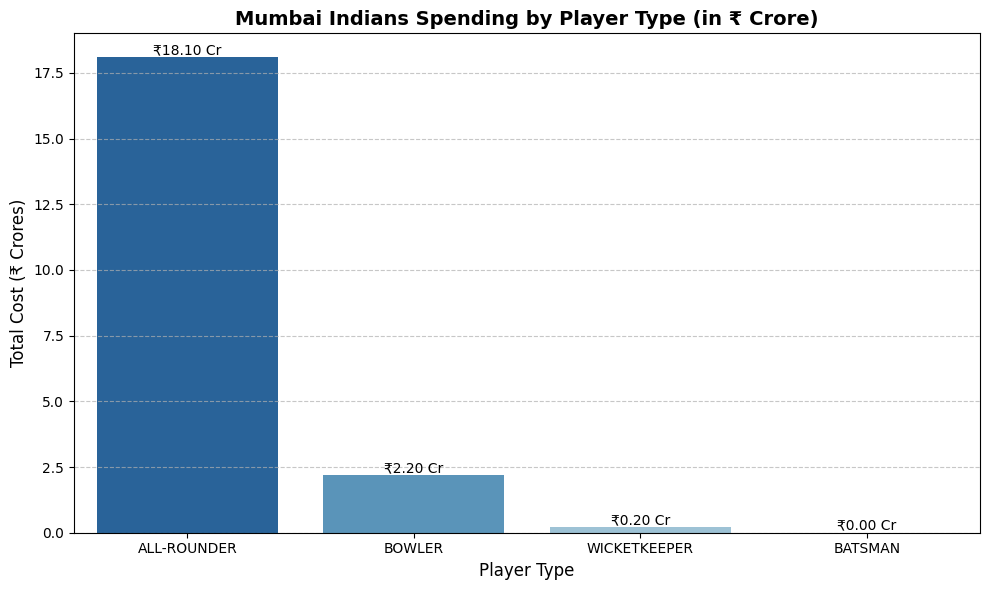

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

mi_df = df[df['Team'] == 'Mumbai Indians']

mi_spending = mi_df.groupby('TYPE')['COST IN ₹ (CR.)'].sum().reset_index()
mi_spending = mi_spending.sort_values(by='COST IN ₹ (CR.)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='TYPE', y='COST IN ₹ (CR.)', data=mi_spending, hue='TYPE', palette='Blues_r', legend=False, ax=ax)

plt.title('Mumbai Indians Spending by Player Type (in ₹ Crore)', fontsize=14, fontweight='bold')
plt.xlabel('Player Type', fontsize=12)
plt.ylabel('Total Cost (₹ Crores)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"₹{p.get_height():.2f} Cr", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [33]:

most_expensive_idx = df['COST IN ₹ (CR.)'].idxmax()
most_expensive_player = df.loc[[most_expensive_idx]]

display(most_expensive_player)

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
97,Sam Curran,20000000,ALL-ROUNDER,18.5,2220.0,NaN,Punjab Super Kings


,Player Type,Count
0,ALL-ROUNDER,213
1,BOWLER,189
2,BATSMAN,91
3,WICKETKEEPER,75


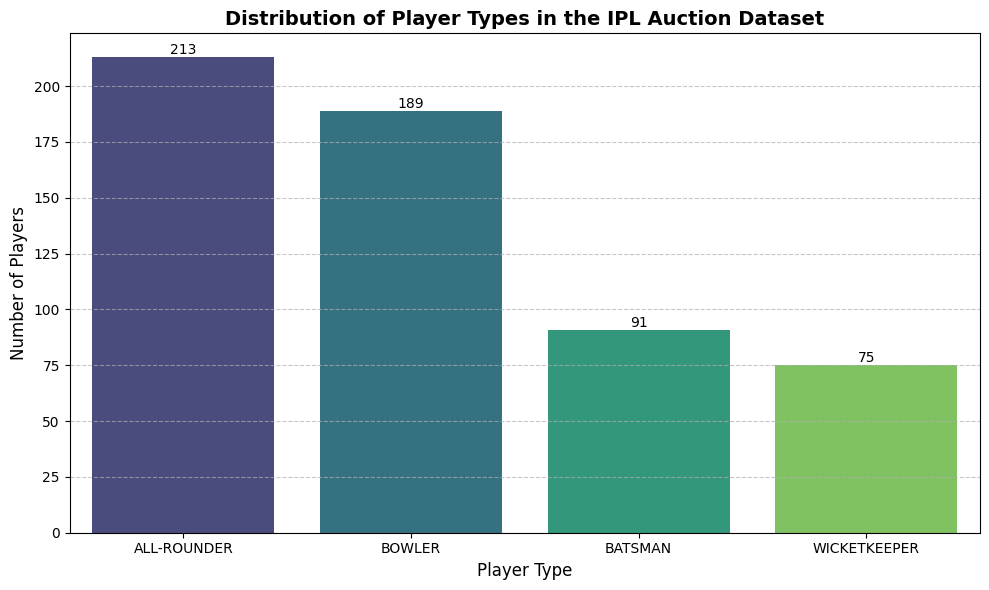

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

player_type_counts = df['TYPE'].value_counts().reset_index()
player_type_counts.columns = ['Player Type', 'Count']

display(player_type_counts)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Player Type', y='Count', data=player_type_counts, hue='Player Type', palette='viridis', legend=False, ax=ax)

plt.title('Distribution of Player Types in the IPL Auction Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Player Type', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

Average Cost by Player Type across all teams:


,TYPE,COST IN ₹ (CR.)
3,WICKETKEEPER,0.920000
1,BATSMAN,0.890244
0,ALL-ROUNDER,0.813218
2,BOWLER,0.378235


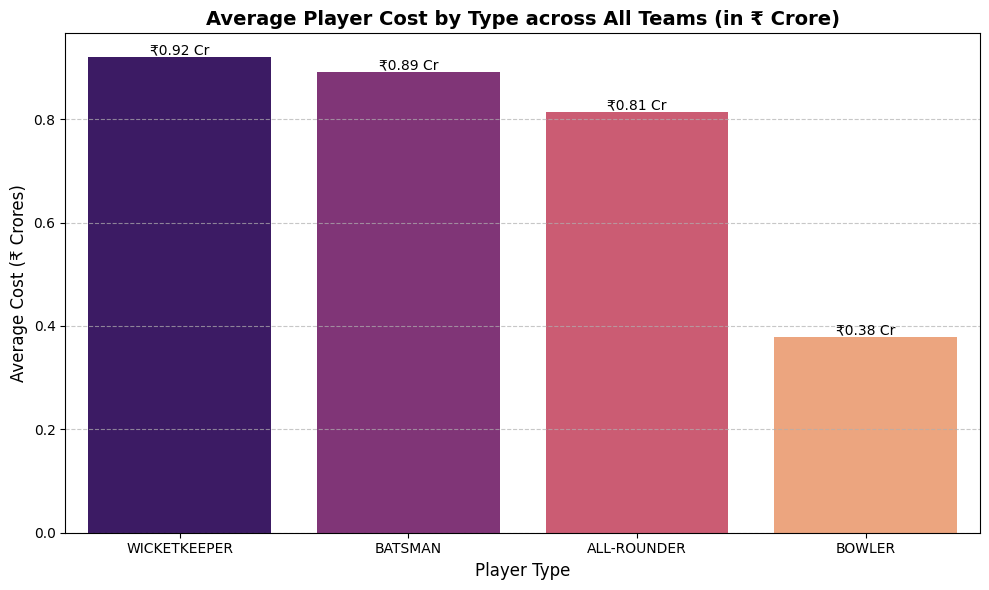

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_cost_by_type = df.groupby('TYPE')['COST IN ₹ (CR.)'].mean().reset_index()
avg_cost_by_type = avg_cost_by_type.sort_values(by='COST IN ₹ (CR.)', ascending=False)

print("Average Cost by Player Type across all teams:")
display(avg_cost_by_type)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='TYPE', y='COST IN ₹ (CR.)', data=avg_cost_by_type, hue='TYPE', palette='magma', legend=False, ax=ax)

plt.title('Average Player Cost by Type across All Teams (in ₹ Crore)', fontsize=14, fontweight='bold')
plt.xlabel('Player Type', fontsize=12)
plt.ylabel('Average Cost (₹ Crores)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"₹{p.get_height():.2f} Cr", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [36]:

all_rounders_df = df[df['TYPE'] == 'ALL-ROUNDER']

all_rounders_spending = all_rounders_df.groupby('Team')['COST IN ₹ (CR.)'].sum().reset_index()
all_rounders_spending = all_rounders_spending.sort_values(by='COST IN ₹ (CR.)', ascending=False)

print("Total spending on All-Rounders by Team:")
display(all_rounders_spending)

top_spending_team = all_rounders_spending.iloc[0]
print(f"\n🏆 The team that spent the most on All-Rounders overall is: {top_spending_team['Team']} with a total of ₹{top_spending_team['COST IN ₹ (CR.)']:.2f} Crores.")

Total spending on All-Rounders by Team:


,Team,COST IN ₹ (CR.)
6,Punjab Super Kings,19.20
5,Mumbai Indians,18.10
0,Chennai Super Kings,17.25
7,Rajasthan Royals,6.15
9,Sunrisers Hyderabad,4.80
3,Kolkata Knight Riders,2.50
4,Lucknow Super Giants,1.85
2,Gujarat Titans,0.50
8,Royal Challengers Banglore,0.40
1,Delhi Capitals,0.00



🏆 The team that spent the most on All-Rounders overall is: Punjab Super Kings with a total of ₹19.20 Crores.


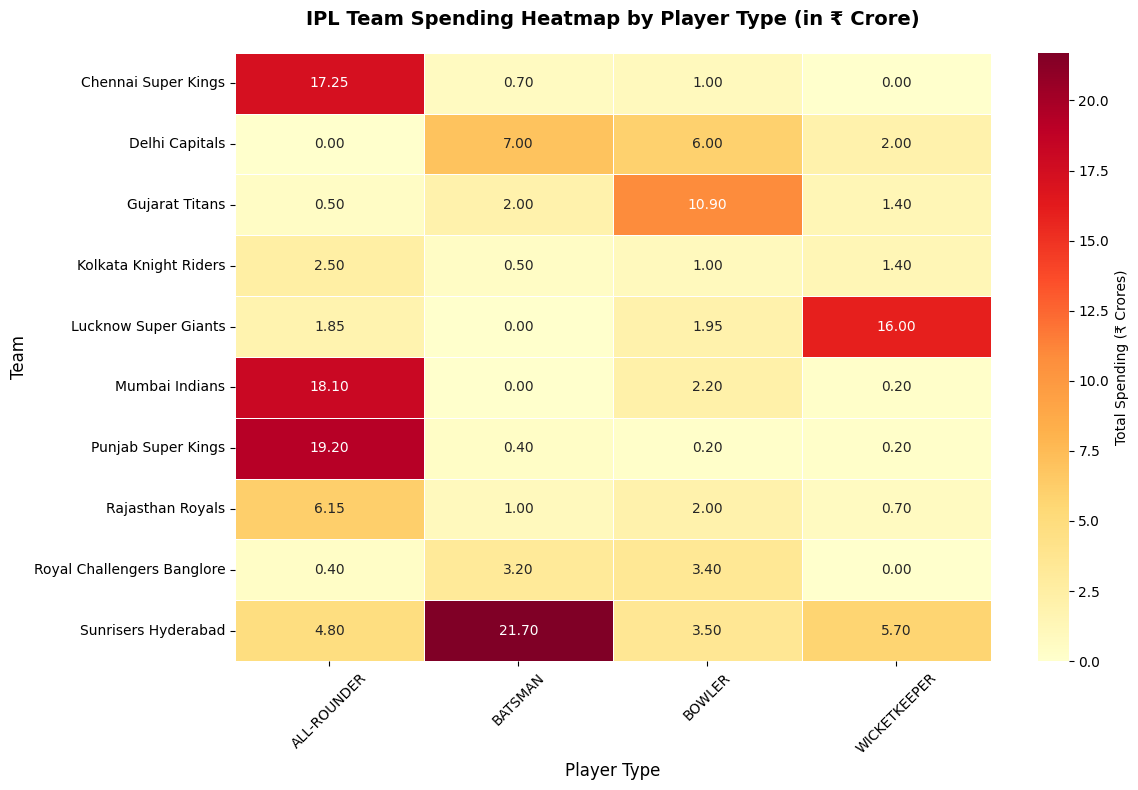

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

active_teams_df = df[df['Team'] != 'Unsold']


spending_pivot = active_teams_df.pivot_table(
    index='Team',
    columns='TYPE',
    values='COST IN ₹ (CR.)',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    spending_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Total Spending (₹ Crores)'}
)

plt.title('IPL Team Spending Heatmap by Player Type (in ₹ Crore)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Player Type', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total Spending per Team (in ₹ Crores):


,Team,COST IN ₹ (CR.)
9,Sunrisers Hyderabad,35.70
5,Mumbai Indians,20.50
6,Punjab Super Kings,20.00
4,Lucknow Super Giants,19.80
0,Chennai Super Kings,18.95
1,Delhi Capitals,15.00
2,Gujarat Titans,14.80
7,Rajasthan Royals,9.85
8,Royal Challengers Banglore,7.00
3,Kolkata Knight Riders,5.40


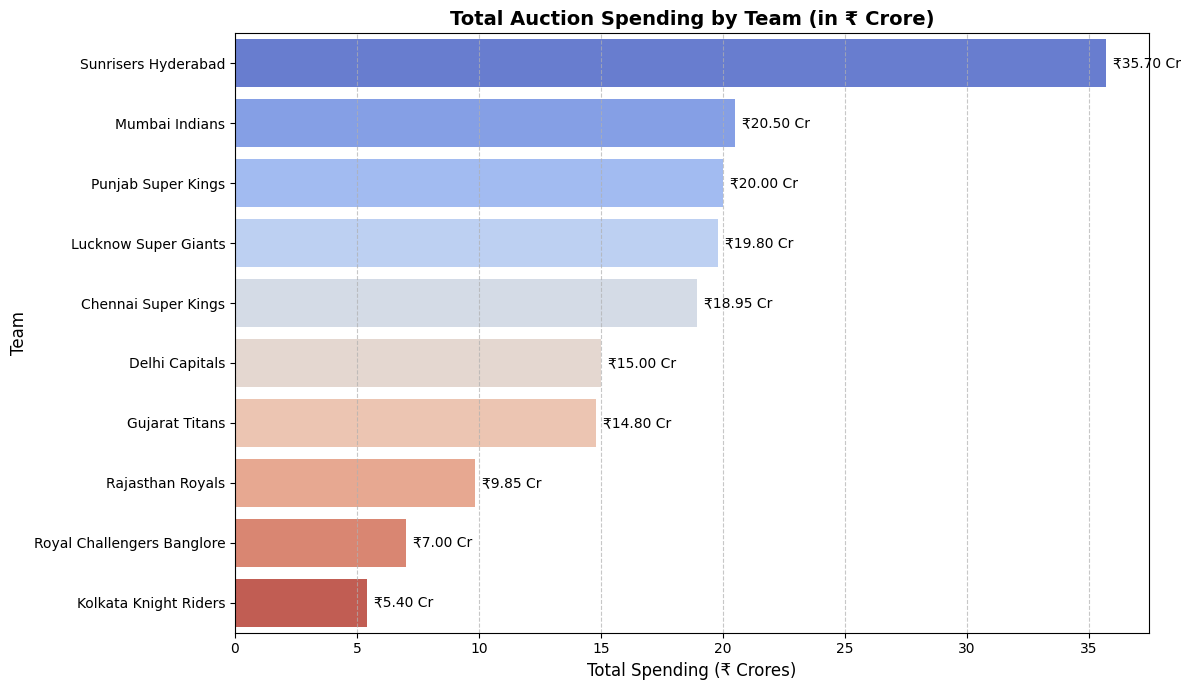

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

active_teams_df = df[df['Team'] != 'Unsold']

total_spending_by_team = active_teams_df.groupby('Team')['COST IN ₹ (CR.)'].sum().reset_index()
total_spending_by_team = total_spending_by_team.sort_values(by='COST IN ₹ (CR.)', ascending=False)

print("Total Spending per Team (in ₹ Crores):")
display(total_spending_by_team)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    x='COST IN ₹ (CR.)',
    y='Team',
    data=total_spending_by_team,
    hue='Team',
    palette='coolwarm',
    legend=False,
    ax=ax
)

plt.title('Total Auction Spending by Team (in ₹ Crore)', fontsize=14, fontweight='bold')
plt.xlabel('Total Spending (₹ Crores)', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"₹{width:.2f} Cr", (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()